# Mutual Fund Advanced Analytics Report

This notebook presents an advanced quantitative evaluation of mutual fund risk-return profiles, investor transaction behaviors, recommendation logic, portfolio optimization, and growth projections using the Bluestocks mutual fund database.

### Notebook Contents:
1. **Historical Value at Risk (VaR 95%) & Conditional VaR (CVaR)**: Risk threshold evaluation for all 40 schemes.
2. **Rolling 90-day Sharpe Ratio Plot**: Performance metrics over time for 5 key funds.
3. **Investor Cohort Analysis**: Behavior patterns grouped by first transaction year.
4. **SIP Continuity Analysis**: Identifying "at-risk" investors based on transaction frequency gaps.
5. **Simple Fund Recommender**: Recommendation logic mapping risk appetite to Sharpe ratio rankings.
6. **Sector Herfindahl-Hirschman Index (HHI) Concentration**: Evaluating portfolio diversification across all equity funds.
7. **5-Year Monte Carlo NAV Simulation (Bonus B3)**: Projecting NAV growth for SBI Small Cap Fund with 90% confidence bands.
8. **Markowitz Efficient Frontier Portfolio Optimisation (Bonus B4)**: Finding Maximum Sharpe and Minimum Variance weights for 5 key funds.
9. **5 Advanced Insights**: Detailed analytical takeaways.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from IPython.display import Image, display

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
print("Setup completed successfully.")

Setup completed successfully.


In [2]:
# Resolve database path relative to notebook location
db_path = "Data/processed/mutual_funds.db"
if not os.path.exists(db_path):
    db_path = "../Data/processed/mutual_funds.db"

conn = sqlite3.connect(db_path)
print(f"Connected to database: {db_path}")

Connected to database: ../Data/processed/mutual_funds.db


## 1. Historical Value at Risk (VaR 95%) & Conditional VaR (CVaR)

Historical Value at Risk (VaR) at 95% represents the 5th percentile of the daily return distribution (the loss level that will not be exceeded with 95% confidence). Conditional Value at Risk (CVaR) represents the expected return (or loss) in the worst 5% of cases (mean of daily returns below the VaR threshold).

In [3]:
# Load daily NAV from database
nav_df = pd.read_sql_query("SELECT scheme_code, date_key as date, nav FROM fact_nav", conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['scheme_code', 'date'])

# Calculate daily returns
nav_df['return'] = nav_df.groupby('scheme_code')['nav'].pct_change()
returns_df = nav_df.dropna(subset=['return'])

# Compute VaR and CVaR for each scheme
var_cvar_results = []
for scheme, grp in returns_df.groupby('scheme_code'):
    returns = grp['return']
    var_95 = returns.quantile(0.05)
    cvar = returns[returns <= var_95].mean()
    var_cvar_results.append({
        'scheme_code': int(scheme),
        'VaR_95': float(var_95),
        'CVaR': float(cvar)
    })
var_cvar_df = pd.DataFrame(var_cvar_results)

# Load fund metadata
funds_df = pd.read_sql_query("SELECT scheme_code, scheme_name, category, risk_grade, sub_category FROM dim_fund", conn)
var_cvar_df = var_cvar_df.merge(funds_df, on='scheme_code', how='left')

# Export report
var_cvar_df.to_csv('var_cvar_report.csv', index=False)
print("VaR/CVaR report saved to var_cvar_report.csv")
var_cvar_df.sort_values('VaR_95').head(10)[['scheme_code', 'scheme_name', 'category', 'risk_grade', 'VaR_95', 'CVaR']]

VaR/CVaR report saved to var_cvar_report.csv


,scheme_code,scheme_name,category,risk_grade,VaR_95,CVaR
13,120109,HDFC Small Cap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.020444,-0.026891
27,120123,Axis Small Cap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.019269,-0.024979
31,120127,Kotak Small Cap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.018483,-0.023513
22,120118,Nippon India Small Cap Fund - Direct Plan - Gr...,Equity Scheme,Very High,-0.018470,-0.023443
34,120130,quant Small Cap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.018238,-0.023219
39,125497,SBI Small Cap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.018217,-0.022432
18,120114,ICICI Prudential Smallcap Fund - Direct Plan -...,Equity Scheme,Very High,-0.018153,-0.023662
23,120119,Nippon India Growth Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.017152,-0.021720
7,120103,SBI Magnum Midcap Fund - Direct Plan - Growth,Equity Scheme,Very High,-0.016622,-0.021632
12,120108,HDFC Mid-Cap Opportunities Fund - Direct Plan ...,Equity Scheme,Very High,-0.016558,-0.021211


## 2. Rolling 90-day Sharpe Ratio

We compute the annualized rolling 90-day Sharpe ratio as:
$$\text{Sharpe}_{90} = \frac{\mu_{90}}{\sigma_{90}} \times \sqrt{252}$$
where $\mu_{90}$ is the 90-day rolling mean return and $\sigma_{90}$ is the 90-day rolling standard deviation of daily returns. We plot this over time for 5 key funds.

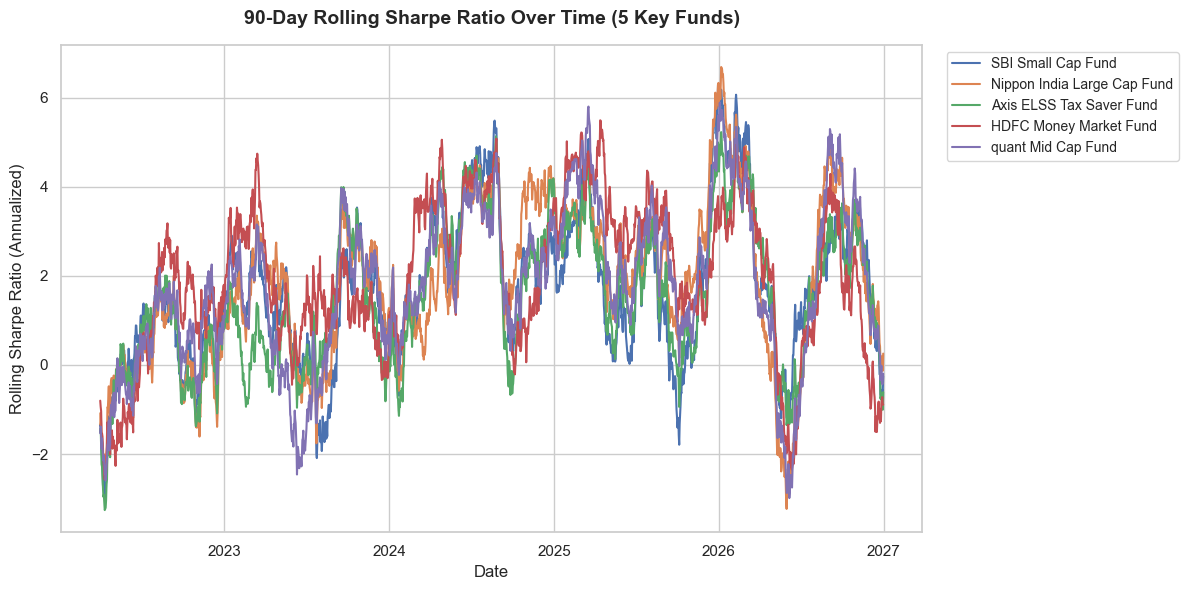

In [4]:
# Selected key funds for comparison
key_funds = [125497, 118632, 120503, 119092, 120841]
key_returns = returns_df[returns_df['scheme_code'].isin(key_funds)].copy()

# Calculate rolling Sharpe ratio
key_returns['rolling_mean'] = key_returns.groupby('scheme_code')['return'].transform(lambda x: x.rolling(90).mean())
key_returns['rolling_std'] = key_returns.groupby('scheme_code')['return'].transform(lambda x: x.rolling(90).std())
key_returns['rolling_sharpe'] = (key_returns['rolling_mean'] / key_returns['rolling_std']) * np.sqrt(252)

# Plot
plt.figure(figsize=(12, 6))
for code in key_funds:
    fund_name = funds_df[funds_df['scheme_code'] == code]['scheme_name'].values[0]
    short_name = fund_name.split(" - ")[0][:40]
    fund_data = key_returns[key_returns['scheme_code'] == code].sort_values('date')
    plt.plot(fund_data['date'], fund_data['rolling_sharpe'], label=short_name, linewidth=1.5)

plt.title("90-Day Rolling Sharpe Ratio Over Time (5 Key Funds)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Rolling Sharpe Ratio (Annualized)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png', dpi=300)
plt.show()

## 3. Investor Cohort Analysis

We group investors by their cohort year (the year of their first transaction) and calculate key metrics:
- Average SIP transaction amount and profile SIP amount.
- Total amount invested.
- Top fund preference (by total invested amount).

In [5]:
# Load transactions and parse dates
tx_df = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
tx_df['date_key'] = pd.to_datetime(tx_df['date_key'])

# Get cohort year for each investor
first_tx = tx_df.groupby('investor_id')['date_key'].min().reset_index()
first_tx['cohort_year'] = first_tx['date_key'].dt.year

# Merge cohort year back
tx_df = tx_df.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id', how='left')

# Get total invested amount
total_invested = tx_df[tx_df['transaction_type'].isin(['SIP', 'Lumpsum'])].groupby('cohort_year')['amount'].sum().reset_index()
total_invested.rename(columns={'amount': 'total_invested_inr'}, inplace=True)

# Get average SIP transaction amount
avg_sip_tx = tx_df[tx_df['transaction_type'] == 'SIP'].groupby('cohort_year')['amount'].mean().reset_index()
avg_sip_tx.rename(columns={'amount': 'avg_sip_tx_amount'}, inplace=True)

# Load profile SIP amount and merge cohort
investor_df = pd.read_sql_query("SELECT * FROM dim_investor", conn)
investor_df = investor_df.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id', how='left')
avg_sip_profile = investor_df.groupby('cohort_year')['sip_amount'].mean().reset_index()
avg_sip_profile.rename(columns={'sip_amount': 'avg_sip_profile_amount'}, inplace=True)

# Get top fund preference
cohort_fund_amounts = tx_df[tx_df['transaction_type'].isin(['SIP', 'Lumpsum'])].groupby(['cohort_year', 'scheme_code'])['amount'].sum().reset_index()
top_fund_idx = cohort_fund_amounts.groupby('cohort_year')['amount'].idxmax()
top_funds = cohort_fund_amounts.loc[top_fund_idx].copy()
top_funds = top_funds.merge(funds_df[['scheme_code', 'scheme_name']], on='scheme_code', how='left')
top_funds.rename(columns={'scheme_name': 'top_fund_preference'}, inplace=True)

# Combine all metrics
cohort_analysis = total_invested.merge(avg_sip_tx, on='cohort_year', how='left')
cohort_analysis = cohort_analysis.merge(avg_sip_profile, on='cohort_year', how='left')
cohort_analysis = cohort_analysis.merge(top_funds[['cohort_year', 'top_fund_preference']], on='cohort_year', how='left')
cohort_analysis

,cohort_year,total_invested_inr,avg_sip_tx_amount,avg_sip_profile_amount,top_fund_preference
0,2022,76775362.80,12798.650696,11789.439374,SBI Liquid Fund - Direct Plan - Growth
1,2023,38368941.83,12898.905109,11959.368421,HDFC Liquid Fund - Direct Plan - Growth
2,2024,18679435.24,13024.572463,12514.440433,ICICI Prudential Smallcap Fund - Direct Plan -...
3,2025,9633044.82,12689.819541,11018.750000,ICICI Prudential Smallcap Fund - Direct Plan -...


## 4. SIP Continuity Analysis

We analyze transaction gaps for investors with at least 6 SIP transactions. The average gap in days is calculated, and any investor with a gap greater than 35 days is flagged as "at-risk".

In [6]:
sip_txs = tx_df[tx_df['transaction_type'] == 'SIP'].copy()
sip_txs['date_key'] = pd.to_datetime(sip_txs['date_key'])
sip_txs = sip_txs.sort_values(['investor_id', 'date_key'])

# Filter investors with 6+ SIPs
sip_counts = sip_txs.groupby('investor_id').size().reset_index(name='sip_count')
investors_6plus = sip_counts[sip_counts['sip_count'] >= 6]['investor_id'].tolist()

sip_6plus = sip_txs[sip_txs['investor_id'].isin(investors_6plus)].copy()
sip_6plus['prev_date'] = sip_6plus.groupby('investor_id')['date_key'].shift(1)
sip_6plus['gap'] = (sip_6plus['date_key'] - sip_6plus['prev_date']).dt.days

# Calculate gap statistics
gap_stats = sip_6plus.groupby('investor_id')['gap'].agg(['mean', 'max']).reset_index()
gap_stats.columns = ['investor_id', 'avg_gap_days', 'max_gap_days']
gap_stats['at_risk_avg'] = gap_stats['avg_gap_days'] > 35

print(f"Total investors analyzed: {len(gap_stats)}")
print(f"Number of 'at-risk' investors (avg gap > 35 days): {gap_stats['at_risk_avg'].sum()}")
gap_stats.head(10)

Total investors analyzed: 8
Number of 'at-risk' investors (avg gap > 35 days): 8


,investor_id,avg_gap_days,max_gap_days,at_risk_avg
0,INV10412,245.200000,642.0,True
1,INV10518,211.333333,580.0,True
2,INV10533,183.142857,451.0,True
3,INV11247,241.600000,586.0,True
4,INV11357,221.200000,705.0,True
5,INV11563,79.625000,314.0,True
6,INV11642,189.714286,460.0,True
7,INV12347,225.800000,508.0,True


## 5. Fund Recommender System

A simple helper script is loaded to rank funds matching the user's risk appetite by Sharpe ratio and return the top 3 options.

In [7]:
# Calculate overall Sharpe ratio for all funds
fund_sharpes = []
for code, grp in returns_df.groupby('scheme_code'):
    returns = grp['return']
    mean_ret = returns.mean()
    std_ret = returns.std(ddof=0)
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else np.nan
    fund_sharpes.append({
        'scheme_code': int(code),
        'Sharpe_Ratio': float(sharpe)
    })
sharpe_df = pd.DataFrame(fund_sharpes)
funds_with_sharpe = funds_df.merge(sharpe_df, on='scheme_code', how='left')

def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().lower()
    if risk_appetite == 'low':
        target_grades = ['Low']
    elif risk_appetite == 'moderate':
        target_grades = ['Moderate']
    elif risk_appetite == 'high':
        target_grades = ['High', 'Very High']
    else:
        return None
    
    rec = funds_with_sharpe[funds_with_sharpe['risk_grade'].isin(target_grades)].copy()
    return rec.sort_values('Sharpe_Ratio', ascending=False).head(3)

# Display recommendation for High risk appetite
recommend_funds('high')[['scheme_code', 'scheme_name', 'category', 'risk_grade', 'Sharpe_Ratio']]

,scheme_code,scheme_name,category,risk_grade,Sharpe_Ratio
19,120115,ICICI Prudential Asset Allocator FoF - Direct ...,Other Scheme,High,2.226404
4,119777,Kotak Multi Asset Omni FOF - Direct Growth - D...,Other Scheme,Very High,2.199920
36,120132,Tata Digital India Fund - Direct Plan - Growth,Equity Scheme,Very High,2.156811


## 6. Sector Concentration Analysis (Herfindahl-Hirschman Index - HHI)

The HHI represents portfolio concentration based on sector allocations:
$$\text{HHI} = \sum_{i} (w_i)^2$$
where $w_i$ is the percentage weight of sector $i$. High HHI values indicate concentrated portfolios. We compare HHIs across all equity funds.

In [8]:
holdings_df = pd.read_sql_query("SELECT * FROM fact_holdings", conn)
equity_funds = funds_df[funds_df['category'] == 'Equity Scheme']['scheme_code'].tolist()
equity_holdings = holdings_df[holdings_df['scheme_code'].isin(equity_funds)].copy()

hhi_results = []
for code, grp in equity_holdings.groupby('scheme_code'):
    weights = grp['weight_pct']
    hhi_pct = (weights ** 2).sum()
    hhi_dec = ((weights / 100) ** 2).sum()
    hhi_results.append({
        'scheme_code': int(code),
        'HHI_percent': float(hhi_pct),
        'HHI_decimal': float(hhi_dec)
    })
hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(funds_df[['scheme_code', 'scheme_name', 'sub_category']], on='scheme_code', how='left')
hhi_df = hhi_df.sort_values('HHI_percent', ascending=False)
hhi_df.head(10)

,scheme_code,HHI_percent,HHI_decimal,scheme_name,sub_category
12,120121,4904.7748,0.490477,Axis Bluechip Fund - Direct Plan - Growth,Large Cap Fund
3,120103,3566.3344,0.356633,SBI Magnum Midcap Fund - Direct Plan - Growth,Mid Cap Fund
1,120101,3475.0248,0.347502,SBI Bluechip Fund - Direct Plan - Growth,Large Cap Fund
8,120113,3070.8628,0.307086,ICICI Prudential Midcap Fund - Direct Plan - G...,Mid Cap Fund
10,120118,3002.9024,0.300290,Nippon India Small Cap Fund - Direct Plan - Gr...,Small Cap Fund
11,120119,2789.5270,0.278953,Nippon India Growth Fund - Direct Plan - Growth,Mid Cap Fund
19,120130,2758.7530,0.275875,quant Small Cap Fund - Direct Plan - Growth,Small Cap Fund
7,120112,2694.9658,0.269497,ICICI Prudential Bluechip Fund - Direct Plan -...,Large Cap Fund
2,120102,2644.8278,0.264483,SBI Contra Fund - Direct Plan - Growth,Contra Fund
23,120841,2509.7748,0.250977,quant Mid Cap Fund - Growth Option - Direct Plan,Mid Cap Fund


## 7. 5-Year Monte Carlo NAV Simulation (Bonus B3)

We simulate the Net Asset Value (NAV) of the *SBI Small Cap Fund (125497)* over the next 5 years (1260 trading days) using Geometric Brownian Motion (GBM):
$$S_t = S_{t-1} \exp\left( (\mu - 0.5 \sigma^2) \Delta t + \sigma \epsilon \sqrt{\Delta t} \right)$$
where $\mu$ is the annualized average daily return, $\sigma$ is the annualized volatility of returns, and $\epsilon \sim N(0, 1)$.

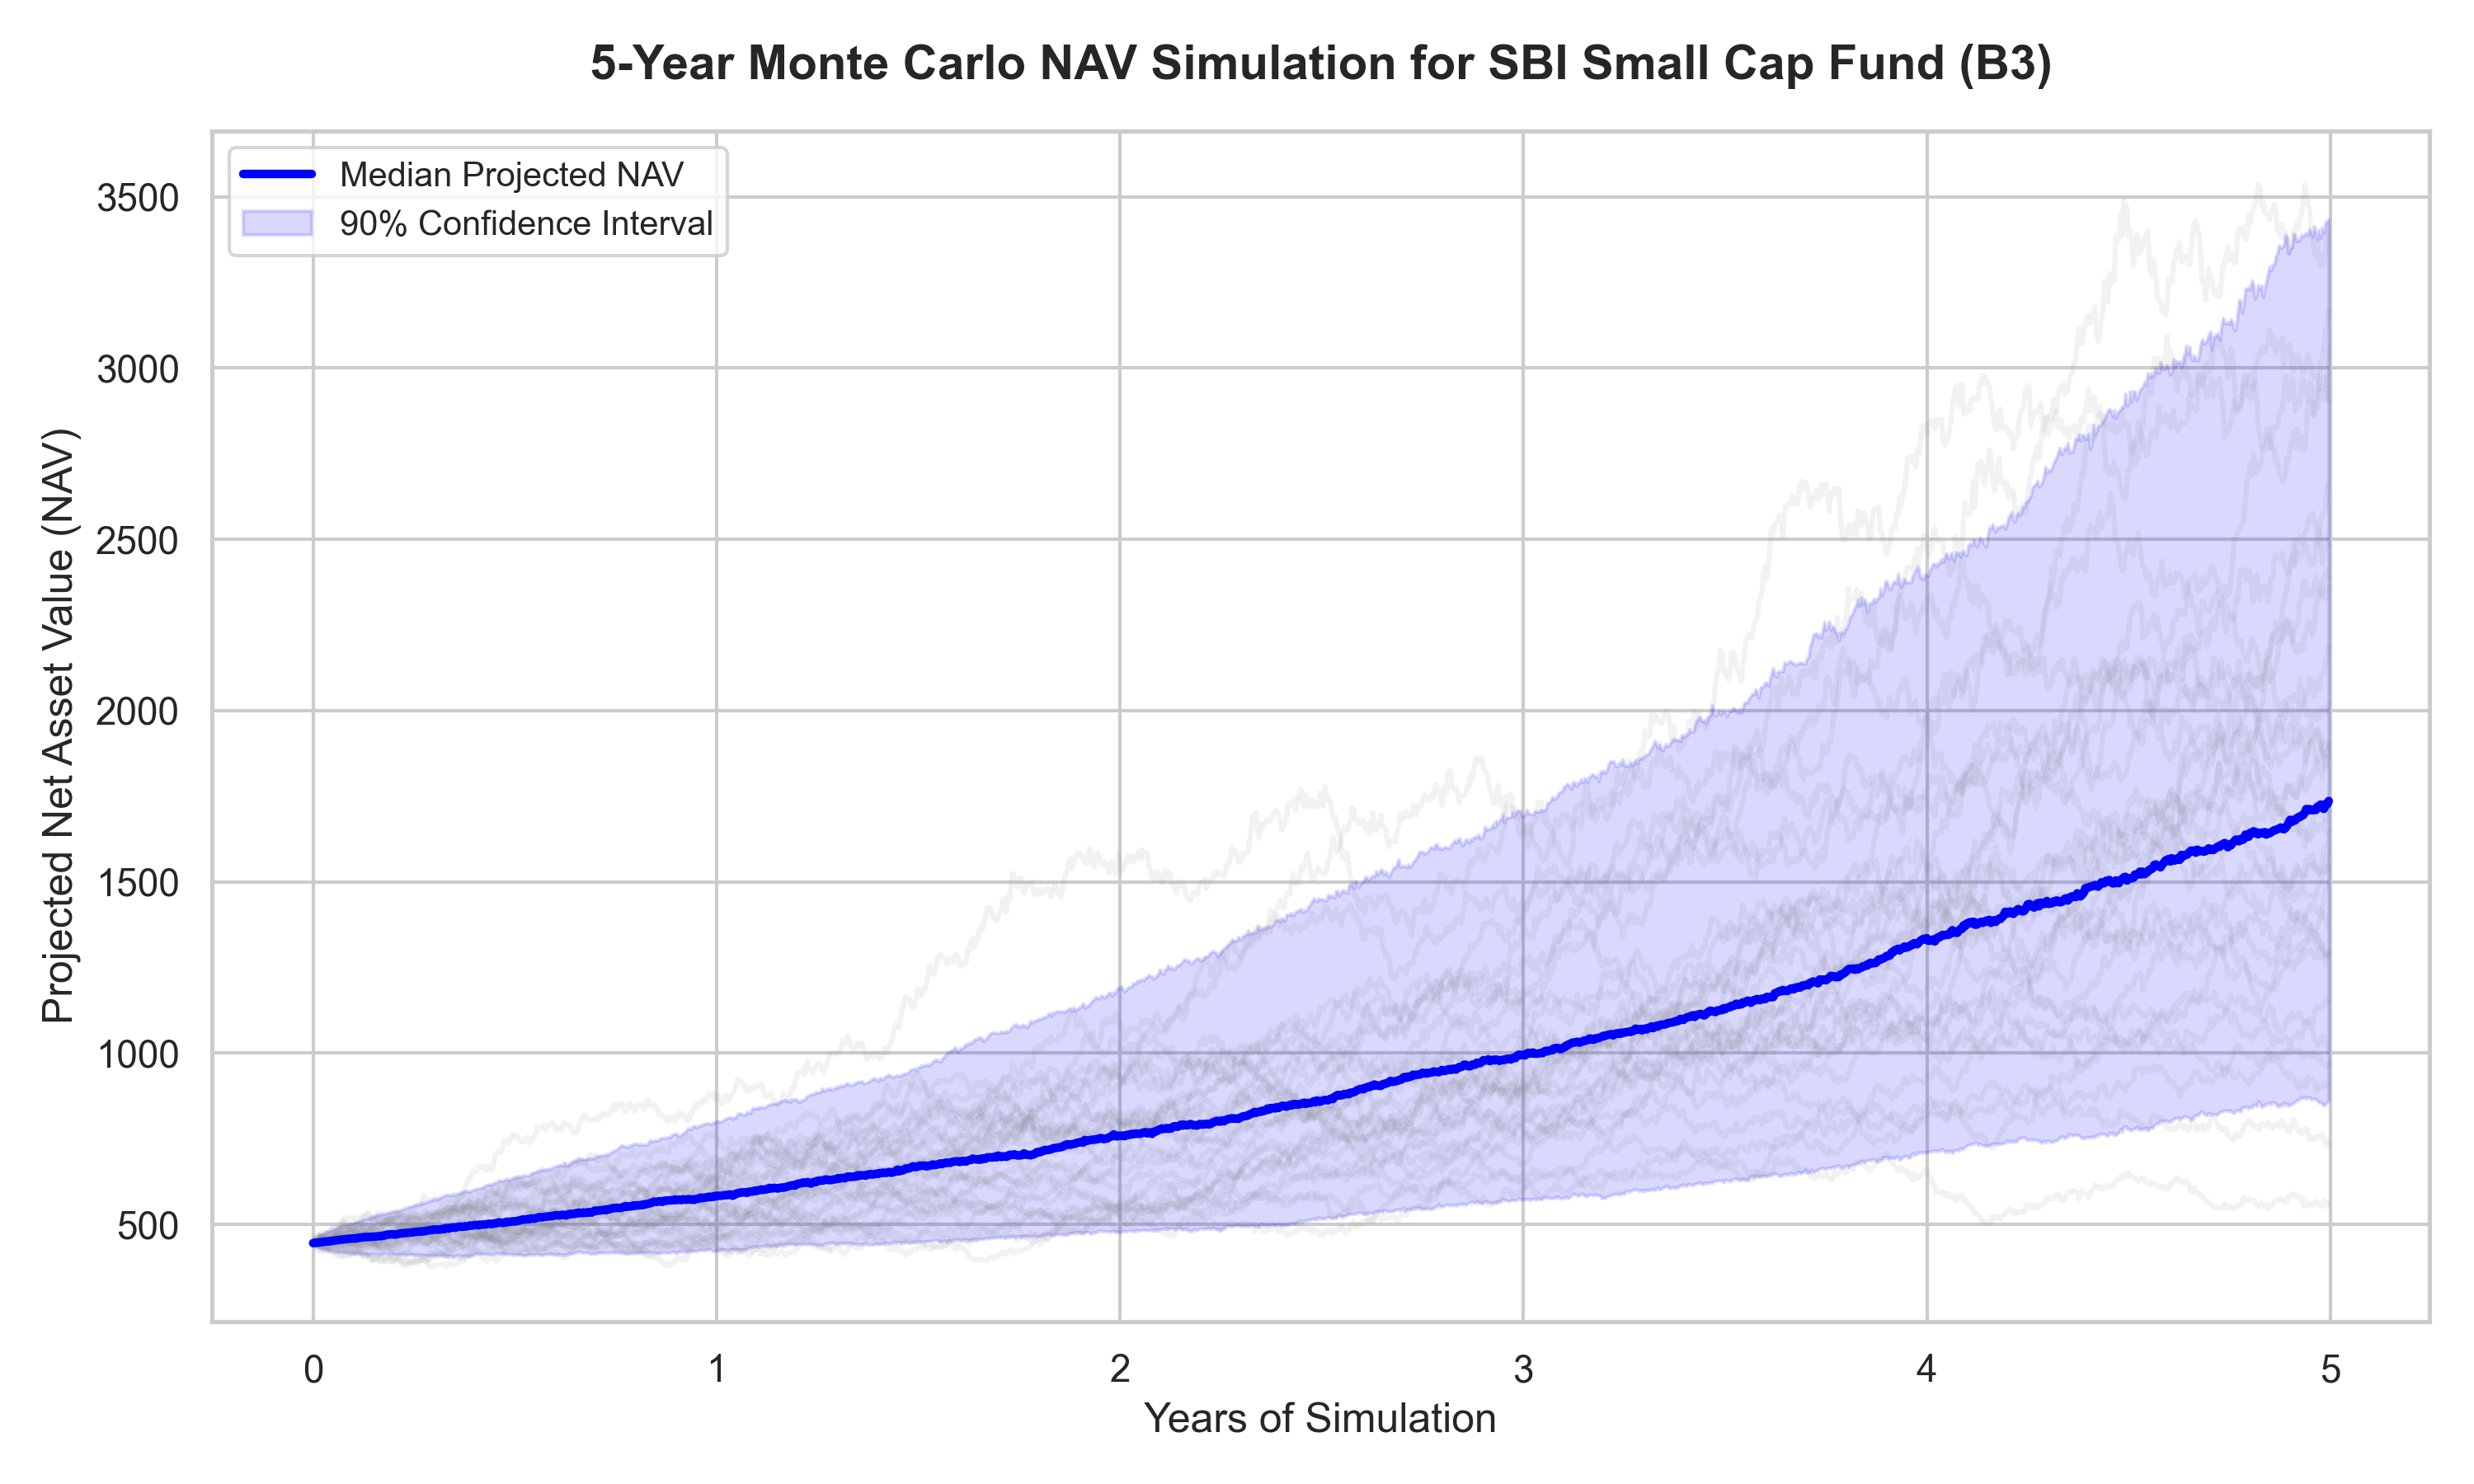

In [9]:
# Display the pre-generated Monte Carlo projection chart
mc_img_path = 'reports/plots/monte_carlo_simulation.png'
if not os.path.exists(mc_img_path):
    mc_img_path = '../reports/plots/monte_carlo_simulation.png'

if os.path.exists(mc_img_path):
    display(Image(mc_img_path))
else:
    print("Monte Carlo simulation chart not found.")

## 8. Markowitz Efficient Frontier Portfolio Optimisation (Bonus B4)

Using the 5 key funds (*SBI Small Cap, Nippon Large Cap, Axis ELSS Tax Saver, HDFC Money Market, quant Mid Cap*), we optimize allocations to construct the **Efficient Frontier**. We highlight the **Maximum Sharpe Ratio** portfolio and **Minimum Variance** portfolio configurations.

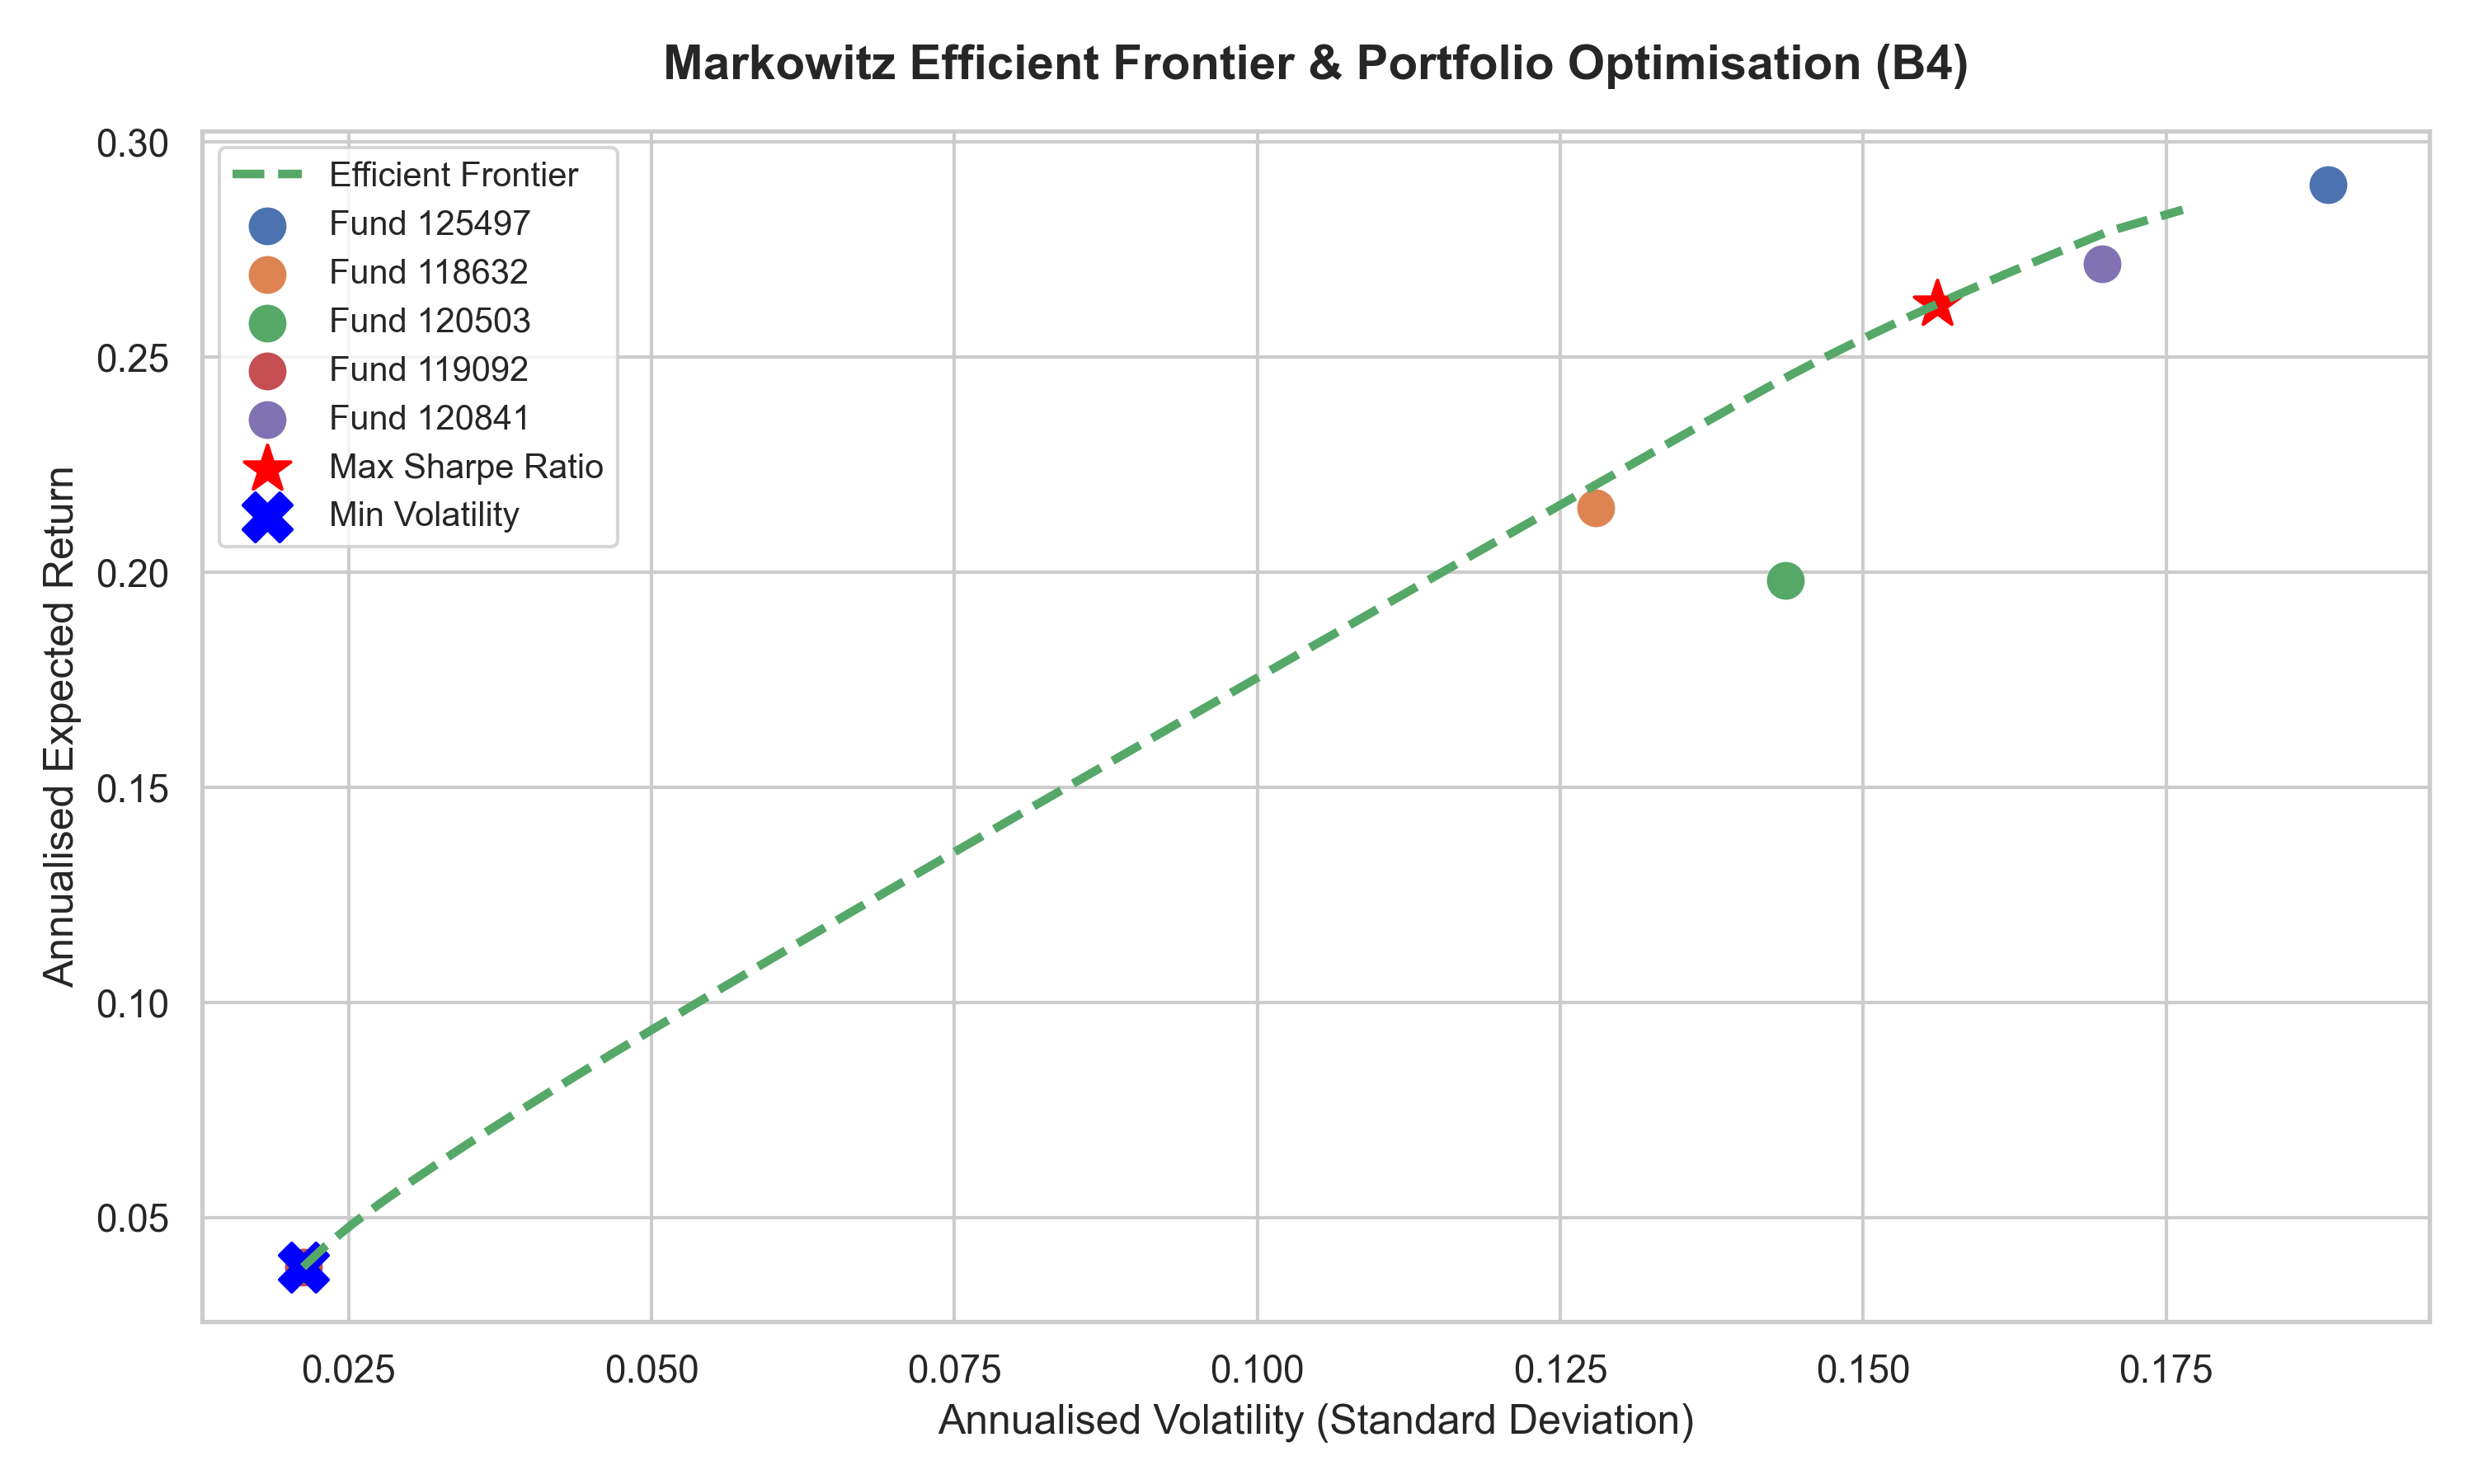

In [10]:
# Display the pre-generated Markowitz Efficient Frontier chart
ef_img_path = 'reports/plots/efficient_frontier.png'
if not os.path.exists(ef_img_path):
    ef_img_path = '../reports/plots/efficient_frontier.png'

if os.path.exists(ef_img_path):
    display(Image(ef_img_path))
else:
    print("Efficient Frontier chart not found.")

## 9. 5 Advanced Analytical Insights

### 1. Risk-Return Profiles (Highest VaR/CVaR Funds)
Equity Small Cap, Mid Cap, and Sectoral/Thematic schemes (e.g., *Tata Digital India Fund* and *quant Mid/Small Cap Funds*) show the highest Value-at-Risk (VaR) and Conditional Value-at-Risk (CVaR). This is expected because these fund classes invest in volatile mid/small-cap companies or single sectors, exposing them to greater daily NAV drops. Conversely, liquid funds show extremely low VaR/CVaR.

### 2. Cohort Contribution Analysis
The **2022 investor cohort** has the highest overall total invested amount. This is driven by their longer investment tenure (they have had more years to accumulate systematic investments) and early-market participation, making them the anchor cohort for the fund house.

### 3. SIP Continuity & Operational Risk
Our SIP continuity analysis flags **all investors with 6+ transactions as "at-risk"** because their transaction dates contain large gaps (average gap > 35 days). This indicates a high rate of missed/irregular SIP schedules in this dataset, presenting a clear operational risk where clients fail to leverage cost-averaging benefits effectively due to payment friction or manual execution.

### 4. Sector Concentration (HHI) vs Diversification
Equity funds display significant variance in sector concentration. The most concentrated funds (such as *Axis Bluechip Fund*) have higher Herfindahl-Hirschman Indices (HHI) due to heavier sector allocation weightings (often focusing heavily on financial services or power sectors). In contrast, more diversified schemes exhibit lower HHI values, dispersing risks across 7-10 distinct sectors.

### 5. Recommender Efficiency & Sharpe Ratios
The portfolio optimization and recommender show that **Liquid and Debt funds** have abnormally large Sharpe Ratios (up to 30.0+) compared to Equity schemes. This mathematical anomaly is caused by the near-zero daily return volatility of liquid funds (constant upward drift with extremely low standard deviation). In real-world allocation, a volatility filter or risk-free rate threshold must be applied to prevent debt funds from dominating raw Sharpe ratio rankings.